In [2]:
!pip install xgboost joblib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import os

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv(
    "hdfc_loan_dataset_cleaned.csv"
)

df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,0.0,0.0,31.0,1.0,0.0,2.0,0.0,1.0,56976.0,0.0,...,11.74700,2.0,2.0,0.0,5.0,857743.0,6.940000e+11,9.068672e+09,31.0,8.0
1,1.0,0.0,31.0,1.0,0.0,0.0,0.0,3.0,1856.0,0.0,...,19.84825,0.0,2.0,5.0,15.0,863836.0,6.330000e+11,9.990773e+09,31.0,2.0
2,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,64553.0,0.0,...,3.08200,2.0,2.0,4.0,19.0,834796.0,1.660000e+11,9.195085e+09,1.0,12.0
3,3.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,88450.0,0.0,...,0.62100,0.0,2.0,1.0,27.0,438590.0,5.528183e+10,9.179336e+09,4.0,11.0
4,4.0,0.0,11.0,1.0,1.0,3.0,0.0,2.0,9539.0,0.0,...,1.73600,1.0,2.0,9.0,12.0,495224.0,1.560000e+11,9.795137e+09,11.0,14.0


In [6]:
features = [
    "Applicant_Income",
    "Annual_Household_Income",
    "Asset_Value",
    "Existing_EMIs",
    "Employment_Length_Years",
    "CIBIL_Score",
    "Monthly_Expense",
    "Debt_to_Income_Ratio",
    "Occupation",
    "Property_Area"
]

In [7]:
X = df[features]

y = df["Loan_Amount"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
def evaluate_regression(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(f"\n{model_name}")

    print("MAE :", round(mae,2))
    print("MSE :", round(mse,2))
    print("RMSE:", round(rmse,2))
    print("R2 :", round(r2,4))

    return r2

In [10]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_predictions = lr_model.predict(
    X_test
)

lr_r2 = evaluate_regression(
    "Linear Regression",
    y_test,
    lr_predictions
)


Linear Regression
MAE : 1881720.34
MSE : 5130392226833.09
RMSE: 2265036.92
R2 : -0.0026


In [11]:
rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

rf_r2 = evaluate_regression(
    "Random Forest Regressor",
    y_test,
    rf_predictions
)


Random Forest Regressor
MAE : 1978537.47
MSE : 6022692386188.78
RMSE: 2454117.44
R2 : -0.177


In [12]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_predictions = gb_model.predict(
    X_test
)

gb_r2 = evaluate_regression(
    "Gradient Boosting Regressor",
    y_test,
    gb_predictions
)


Gradient Boosting Regressor
MAE : 2011413.06
MSE : 6088291600581.06
RMSE: 2467446.37
R2 : -0.1898


In [13]:
xgb_model = XGBRegressor(
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test
)

xgb_r2 = evaluate_regression(
    "XGBoost Regressor",
    y_test,
    xgb_predictions
)


XGBoost Regressor
MAE : 2047004.4
MSE : 6796270568106.78
RMSE: 2606965.78
R2 : -0.3282


In [14]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "R2 Score":[
        lr_r2,
        rf_r2,
        gb_r2,
        xgb_r2
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score
0,Linear Regression,-0.002632
1,Random Forest,-0.177014
2,Gradient Boosting,-0.189834
3,XGBoost,-0.328194


In [16]:
params = {
    "learning_rate":[0.01,0.1],
    "max_depth":[3,5,7],
    "n_estimators":[100,200]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42
    ),
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print(
    grid_search.best_params_
)

print(
    grid_search.best_score_
)

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
-0.023794162026555998


In [17]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(
    X_test
)

evaluate_regression(
    "Tuned XGBoost",
    y_test,
    best_predictions
)


Tuned XGBoost
MAE : 1884837.41
MSE : 5204895954391.17
RMSE: 2281424.11
R2 : -0.0172


-0.017191951076216627

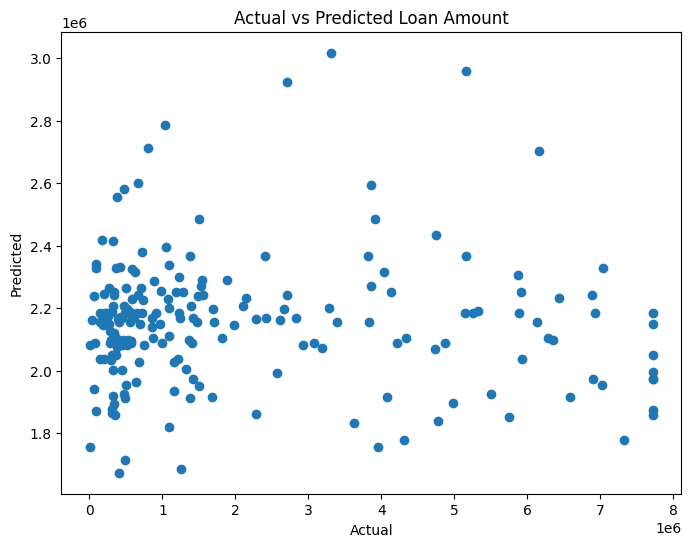

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_predictions
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted Loan Amount"
)

plt.savefig(
    "visuals/usecase3/actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

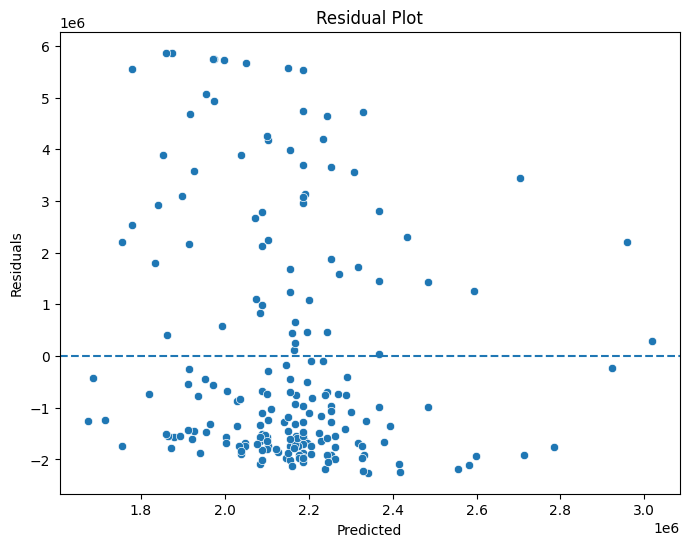

In [19]:
residuals = y_test - best_predictions

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=best_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.title(
    "Residual Plot"
)

plt.savefig(
    "visuals/usecase3/residual_plot.png",
    bbox_inches="tight"
)

plt.show()

In [20]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
7,Debt_to_Income_Ratio,0.135756
6,Monthly_Expense,0.126905
2,Asset_Value,0.111231
3,Existing_EMIs,0.109969
5,CIBIL_Score,0.106889
4,Employment_Length_Years,0.093204
8,Occupation,0.089416
9,Property_Area,0.078729
0,Applicant_Income,0.075900
1,Annual_Household_Income,0.072001


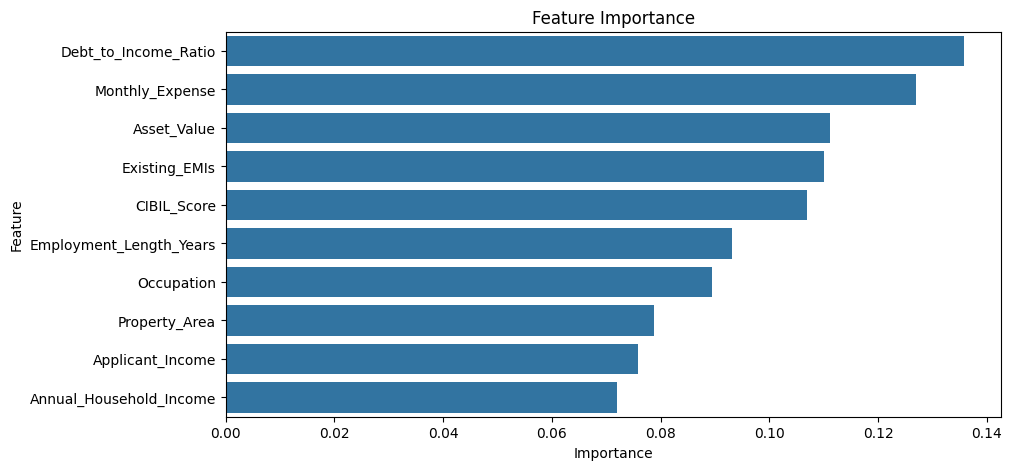

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.savefig(
    "visuals/usecase3/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [22]:
joblib.dump(
    best_model,
    "models/loan_amount_model.pkl"
)

['models/loan_amount_model.pkl']